# Real-World AI-Driven Analytics Solution Using Python  
## Diabetes 130-US Hospitals Readmission Prediction

**Course:** Python Application for Data Analytics  
**Dataset:** Diabetes 130-US Hospitals for Years 1999–2008  
**Source:** UCI Machine Learning Repository  
**Goal:** Build an initial AI-driven analytics solution to predict whether a diabetic patient is likely to be readmitted within 30 days.

---

## Project Overview

This notebook demonstrates the first phase of a real-world healthcare analytics project.  
The workflow includes:

1. Problem framing  
2. Dataset loading  
3. Exploratory data analysis  
4. Missing value treatment  
5. Feature engineering  
6. Data preprocessing  
7. Initial machine learning model development  
8. Model evaluation  
9. Ethical reflection  

The prediction target is **early hospital readmission**, defined as readmission within 30 days.

## 1. Install and Import Required Libraries

We use core Python analytics and machine learning libraries:

- `pandas` and `NumPy` for data handling
- `Matplotlib` and `Seaborn` for visualization
- `scikit-learn` for preprocessing, model training, and evaluation
- `ucimlrepo` to fetch the dataset directly from UCI

In [ ]:
!pip install ucimlrepo -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load Dataset from UCI

The dataset contains hospital encounter records for diabetic patients from 130 U.S. hospitals between 1999 and 2008.

The original target column is `readmitted`, which has three possible values:

- `NO` = patient was not readmitted
- `>30` = patient was readmitted after 30 days
- `<30` = patient was readmitted within 30 days

For this project, we convert the task into a binary classification problem:

- `<30` → `1` = early readmission
- `NO` and `>30` → `0` = no early readmission

In [ ]:
# Fetch dataset from UCI repository
diabetes = fetch_ucirepo(id=296)

# Features and target
X = diabetes.data.features
y = diabetes.data.targets

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Display metadata and variable information
print(diabetes.metadata)

{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

## 3. Initial Dataset Exploration

Before cleaning or modeling, we inspect the dataset structure, data types, missing values, and class distribution.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [ ]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
race,99493,5,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,3197,9,[75-100),1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
payer_code,61510,17,MC,32439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medical_specialty,51817,72,InternalMedicine,14635,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [ ]:
print("Target variable distribution:")
print(df["readmitted"].value_counts())

print("\nTarget variable percentage:")
print(df["readmitted"].value_counts(normalize=True) * 100)

Target variable distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Target variable percentage:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


### Target Distribution Visualization

This chart shows that the classes are not evenly distributed.  
Early readmissions are much smaller than the combined non-early-readmission group, so accuracy alone will not be enough for evaluation.

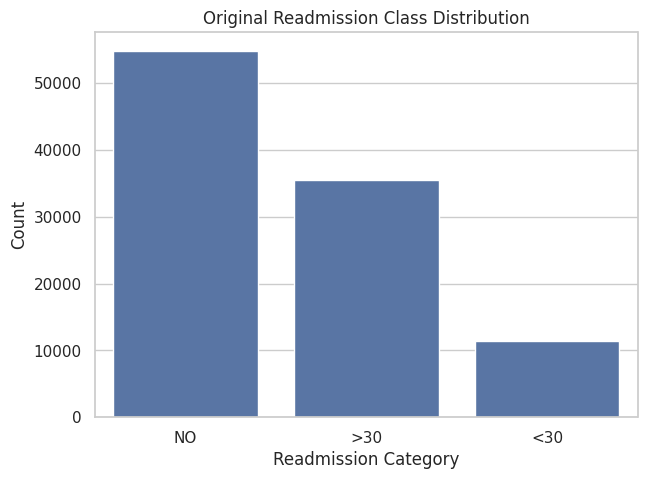

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"])
plt.title("Original Readmission Class Distribution")
plt.xlabel("Readmission Category")
plt.ylabel("Count")
plt.show()

## 4. Missing Value Analysis

This dataset uses both actual missing values and the string `"?"` to represent missing or unavailable information.  
We first replace `"?"` with `NaN`, then calculate missing percentages.

In [ ]:
# Replace question marks with NaN
df = df.replace("?", np.nan)

missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "Missing Percentage": missing_percent,
    "Missing Count": df.isnull().sum()
})

missing_table.head(20)

,Missing Percentage,Missing Count
A1Cresult,83.277322,84748
acarbose,0.000000,0
acetohexamide,0.000000,0
admission_source_id,0.000000,0
admission_type_id,0.000000,0
age,0.000000,0
change,0.000000,0
chlorpropamide,0.000000,0
citoglipton,0.000000,0
diabetesMed,0.000000,0


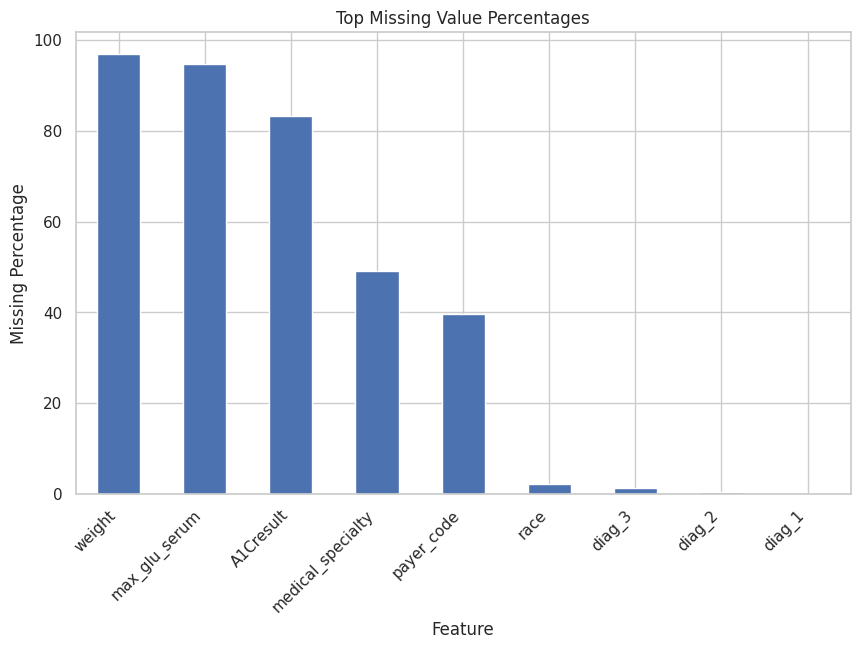

In [ ]:
plt.figure(figsize=(10, 6))
missing_percent[missing_percent > 0].head(15).plot(kind="bar")
plt.title("Top Missing Value Percentages")
plt.ylabel("Missing Percentage")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.show()

## 5. Data Cleaning Decisions

Based on missing value analysis and business meaning, we apply the following cleaning rules:

1. Remove `encounter_id` and `patient_nbr` because they are identifiers, not predictive medical features.
2. Drop columns with extremely high missingness such as `weight`, `payer_code`, and `medical_specialty`.
3. Remove records with invalid or unknown gender.
4. Convert the original `readmitted` target into a binary target named `early_readmission`.
5. Keep demographic variables such as age, race, and gender for exploration, but later discuss their ethical risks.

In [ ]:
df_clean = df.copy()

# Drop identifier columns
identifier_cols = ["encounter_id", "patient_nbr"]
df_clean = df_clean.drop(columns=[col for col in identifier_cols if col in df_clean.columns])

# Drop high-missingness columns if present
high_missing_cols = ["weight", "payer_code", "medical_specialty"]
df_clean = df_clean.drop(columns=[col for col in high_missing_cols if col in df_clean.columns])

# Remove invalid gender records
if "gender" in df_clean.columns:
    df_clean = df_clean[df_clean["gender"] != "Unknown/Invalid"]

# Create binary target
df_clean["early_readmission"] = np.where(df_clean["readmitted"] == "<30", 1, 0)

# Drop original target
df_clean = df_clean.drop(columns=["readmitted"])

print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (101763, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,early_readmission
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


## 6. Feature Engineering

We create additional features that may help the model better understand patient utilization patterns.

### Engineered Features

- `total_prior_visits`: total outpatient, emergency, and inpatient visits before the current encounter
- `medication_change_binary`: whether diabetes medication was changed
- `diabetes_med_binary`: whether diabetes medication was prescribed

In [ ]:
# Create total prior visits feature
visit_cols = ["number_outpatient", "number_emergency", "number_inpatient"]

for col in visit_cols:
    if col not in df_clean.columns:
        df_clean[col] = 0

df_clean["total_prior_visits"] = (
    df_clean["number_outpatient"] +
    df_clean["number_emergency"] +
    df_clean["number_inpatient"]
)

# Convert change and diabetesMed to binary-style categorical indicators
if "change" in df_clean.columns:
    df_clean["medication_change_binary"] = df_clean["change"].map({"Ch": "Yes", "No": "No"})

if "diabetesMed" in df_clean.columns:
    df_clean["diabetes_med_binary"] = df_clean["diabetesMed"].map({"Yes": "Yes", "No": "No"})

df_clean[["total_prior_visits", "early_readmission"]].head()

,total_prior_visits,early_readmission
0,0,0
1,0,0
2,3,0
3,0,0
4,0,0


## 7. Exploratory Data Analysis

EDA helps us understand relationships between features and early readmission.

### 7.1 Binary Target Distribution

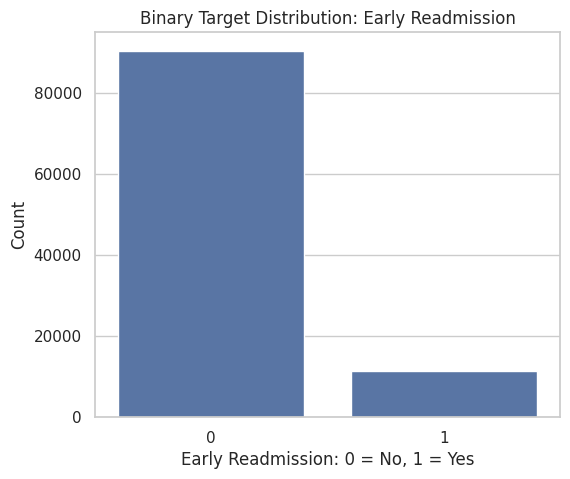

early_readmission
0    88.839755
1    11.160245
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df_clean, x="early_readmission")
plt.title("Binary Target Distribution: Early Readmission")
plt.xlabel("Early Readmission: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

print(df_clean["early_readmission"].value_counts(normalize=True) * 100)

### 7.2 Age Group and Early Readmission

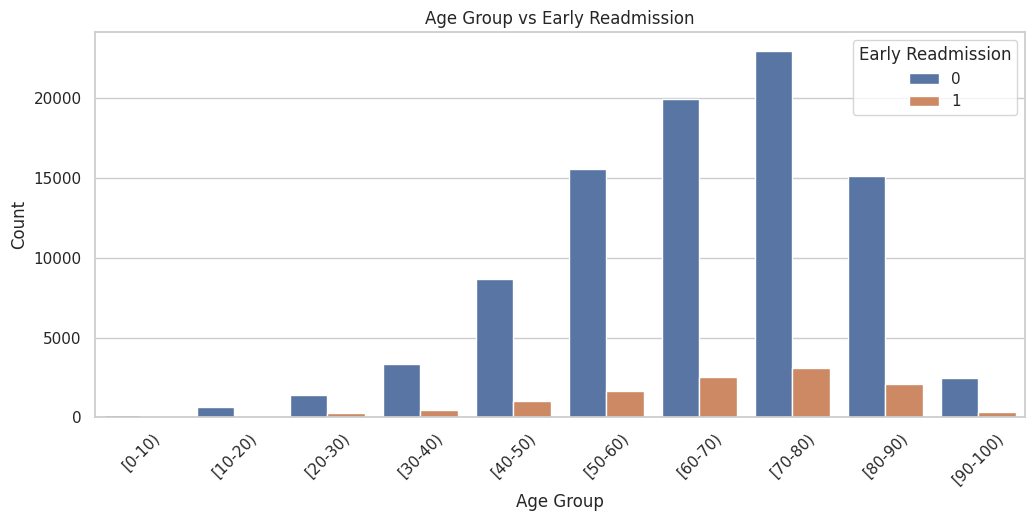

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_clean, x="age", hue="early_readmission")
plt.title("Age Group vs Early Readmission")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Early Readmission")
plt.show()

### 7.3 Time in Hospital and Early Readmission

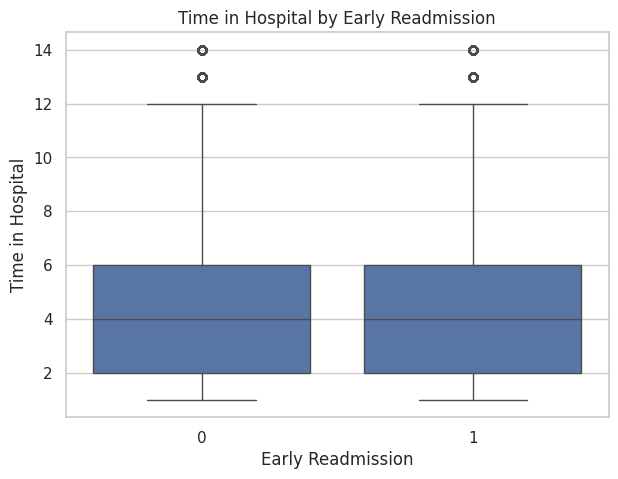

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="early_readmission", y="time_in_hospital")
plt.title("Time in Hospital by Early Readmission")
plt.xlabel("Early Readmission")
plt.ylabel("Time in Hospital")
plt.show()

### 7.4 Number of Medications and Early Readmission

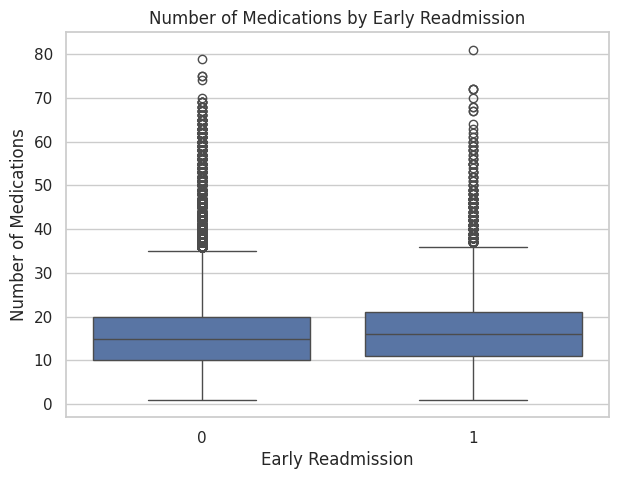

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="early_readmission", y="num_medications")
plt.title("Number of Medications by Early Readmission")
plt.xlabel("Early Readmission")
plt.ylabel("Number of Medications")
plt.show()

### 7.5 Prior Inpatient Visits and Early Readmission

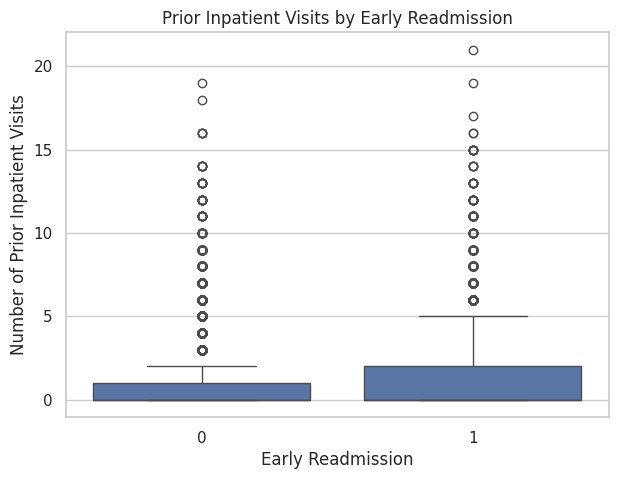

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="early_readmission", y="number_inpatient")
plt.title("Prior Inpatient Visits by Early Readmission")
plt.xlabel("Early Readmission")
plt.ylabel("Number of Prior Inpatient Visits")
plt.show()

### 7.6 Correlation Heatmap for Numerical Features

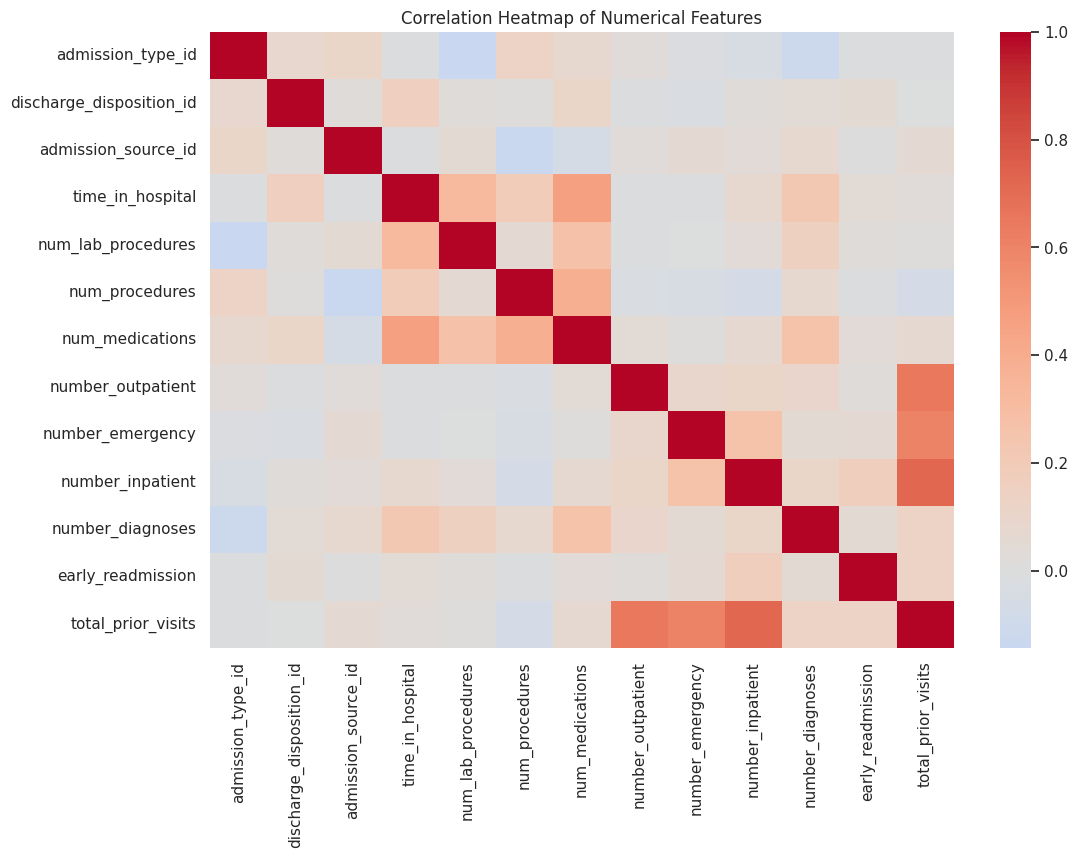

In [ ]:
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## 8. Prepare Features and Target for Modeling

We separate independent variables from the target variable.

The target is:

`early_readmission`

In [ ]:
X = df_clean.drop(columns=["early_readmission"])
y = df_clean["early_readmission"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (101763, 47)
Target shape: (101763,)


In [ ]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 12
Number of categorical features: 35

Numeric features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'total_prior_visits']

Categorical features:
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'medication_change_binary', 'diabetes_med_binary']


## 9. Train-Test Split

We use an 80/20 train-test split.  
Stratification is used to preserve the early readmission ratio in both training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (81410, 47)
Testing set: (20353, 47)

Training target distribution:
early_readmission
0    88.839209
1    11.160791
Name: proportion, dtype: float64

Testing target distribution:
early_readmission
0    88.84194
1    11.15806
Name: proportion, dtype: float64


## 10. Preprocessing Pipeline

We create a reusable preprocessing pipeline:

### Numeric Features
- Median imputation
- Standard scaling

### Categorical Features
- Most frequent value imputation
- One-hot encoding

This prevents data leakage because preprocessing is learned only from the training set.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 11. Helper Function for Model Evaluation

This function evaluates each model using multiple metrics.

Because this is a healthcare readmission problem, **recall** is very important.  
A false negative means the model fails to identify a patient who may return to the hospital within 30 days.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = np.nan

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    }

    print(f"\n{model_name} Evaluation")
    print("-" * 50)
    print("Accuracy:", results["Accuracy"])
    print("Precision:", results["Precision"])
    print("Recall:", results["Recall"])
    print("F1 Score:", results["F1 Score"])
    print("ROC-AUC:", results["ROC-AUC"])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve: {model_name}")
        plt.show()

    return results

## Baseline Model

Before training machine learning models, we created a baseline model using the majority class. This model always predicts the most common outcome. The baseline helps us understand whether Logistic Regression and Random Forest actually improve prediction performance.


Baseline Model Evaluation
--------------------------------------------------
Accuracy: 0.8884193976317988
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20353
   macro avg       0.44      0.50      0.47     20353
weighted avg       0.79      0.89      0.84     20353



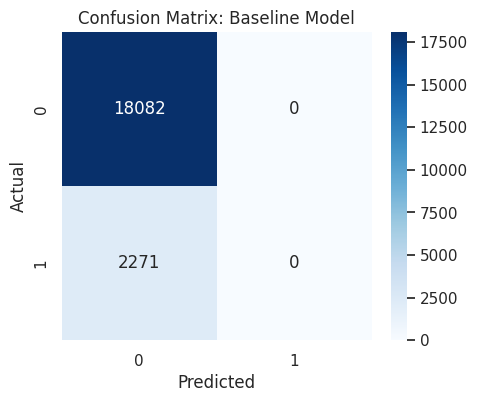

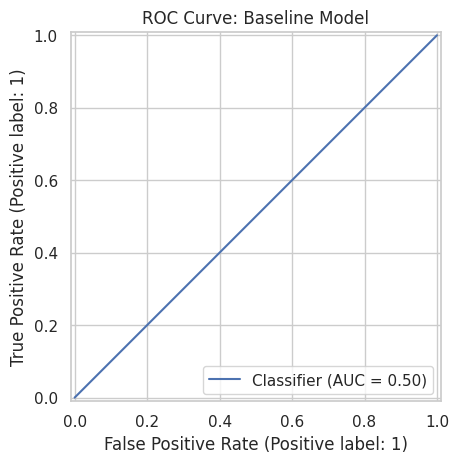

In [ ]:
from sklearn.dummy import DummyClassifier

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Baseline Model"
)

## 12. Model 1: Logistic Regression

Logistic Regression is used as the baseline model because it is fast, interpretable, and commonly used for binary classification.


Logistic Regression Evaluation
--------------------------------------------------
Accuracy: 0.6433449614307473
Precision: 0.16693376068376067
Recall: 0.5504183179216204
F1 Score: 0.2561737882979814
ROC-AUC: 0.6417179899329396

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18082
           1       0.17      0.55      0.26      2271

    accuracy                           0.64     20353
   macro avg       0.54      0.60      0.51     20353
weighted avg       0.84      0.64      0.71     20353



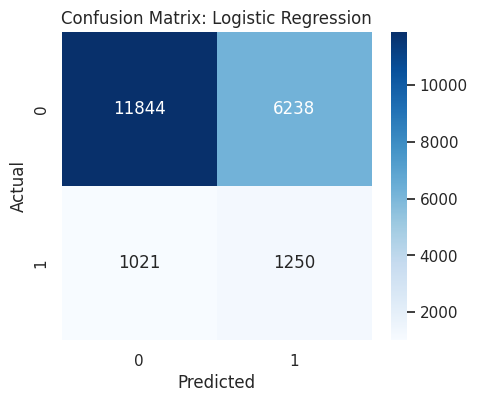

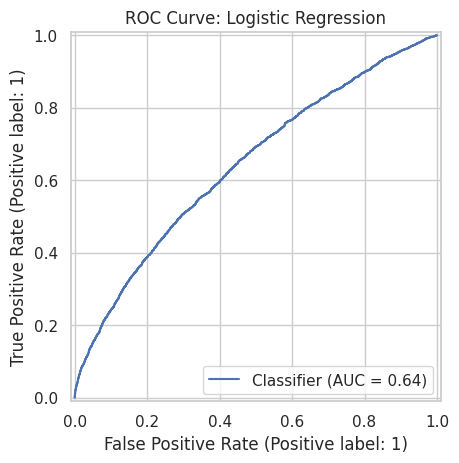

In [ ]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)
logistic_results = evaluate_model(logistic_model, X_test, y_test, "Logistic Regression")

## 13. Model 2: Random Forest Classifier

Random Forest is used as a second initial model because it can capture nonlinear patterns and feature interactions.


Random Forest Evaluation
--------------------------------------------------
Accuracy: 0.6649142632535744
Precision: 0.17418707921501217
Recall: 0.5354469396741524
F1 Score: 0.26286208387375704
ROC-AUC: 0.655822433455576

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     18082
           1       0.17      0.54      0.26      2271

    accuracy                           0.66     20353
   macro avg       0.55      0.61      0.52     20353
weighted avg       0.84      0.66      0.73     20353



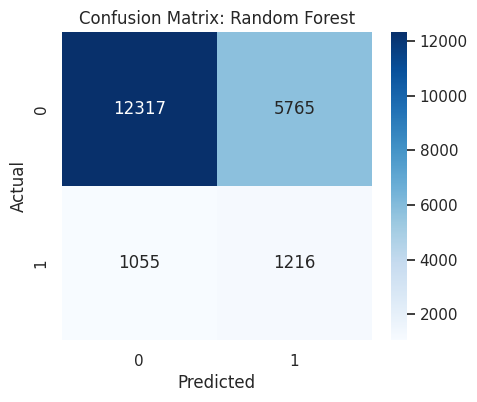

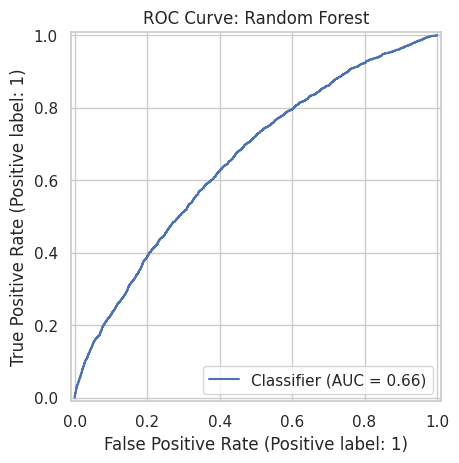

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

## Tuned Random Forest Classifier

To improve model performance, we tested a tuned Random Forest model using GridSearchCV. Since early readmission is the minority class and false negatives are important in healthcare, recall was used as the scoring metric during tuning.

Best parameters:
{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 200}

Tuned Random Forest Evaluation
--------------------------------------------------
Accuracy: 0.6468333906549403
Precision: 0.16977837474815313
Recall: 0.5565830030823425
F1 Score: 0.26018937834499795
ROC-AUC: 0.6539559424746925

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18082
           1       0.17      0.56      0.26      2271

    accuracy                           0.65     20353
   macro avg       0.55      0.61      0.51     20353
weighted avg       0.84      0.65      0.71     20353



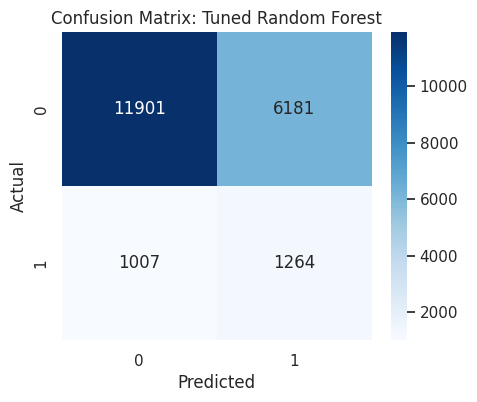

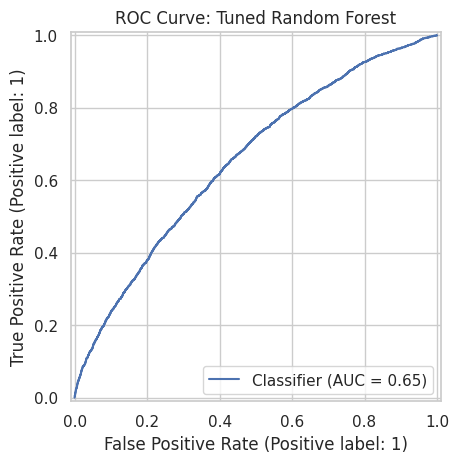

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [8, 12, 16],
    "classifier__min_samples_split": [10, 20],
    "classifier__min_samples_leaf": [2, 5]
}

tuned_rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

grid_search = GridSearchCV(
    tuned_rf_pipeline,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

tuned_rf_model = grid_search.best_estimator_

tuned_rf_results = evaluate_model(
    tuned_rf_model,
    X_test,
    y_test,
    "Tuned Random Forest"
)

## Threshold Tuning for Healthcare Use Case

The default classification threshold is 0.50, but in healthcare, recall is important because missing a high-risk patient can prevent timely follow-up care. We tested different thresholds to understand how precision, recall, and F1-score change.

In [ ]:
from sklearn.metrics import precision_recall_curve

final_model = tuned_rf_model

y_prob = final_model.predict_proba(X_test)[:, 1]

thresholds = [0.20, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.2,0.111581,0.111581,1.000000,0.200760
1,0.3,0.111581,0.111581,1.000000,0.200760
2,0.4,0.113251,0.111691,0.999119,0.200921
3,0.5,0.646833,0.169778,0.556583,0.260189


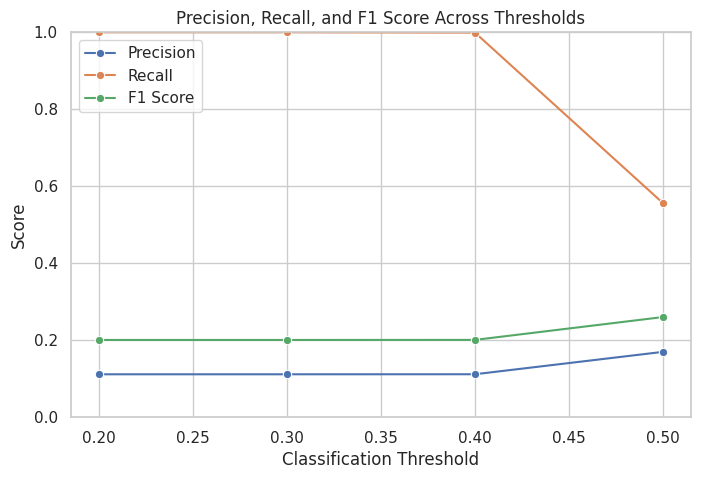

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=threshold_df, x="Threshold", y="Precision", marker="o", label="Precision")
sns.lineplot(data=threshold_df, x="Threshold", y="Recall", marker="o", label="Recall")
sns.lineplot(data=threshold_df, x="Threshold", y="F1 Score", marker="o", label="F1 Score")
plt.title("Precision, Recall, and F1 Score Across Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

Lower thresholds usually increase recall, which means the model identifies more patients who may be readmitted within 30 days. However, lower thresholds can reduce precision by flagging more patients as high-risk. In a hospital setting, this tradeoff may be acceptable if the goal is to avoid missing patients who need follow-up support.

## 14. Model Comparison

In [ ]:
results_df = pd.DataFrame([
    baseline_results,
    logistic_results,
    rf_results,
    tuned_rf_results
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Model,0.888419,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.643345,0.166934,0.550418,0.256174,0.641718
2,Random Forest,0.664914,0.174187,0.535447,0.262862,0.655822
3,Tuned Random Forest,0.646833,0.169778,0.556583,0.260189,0.653956


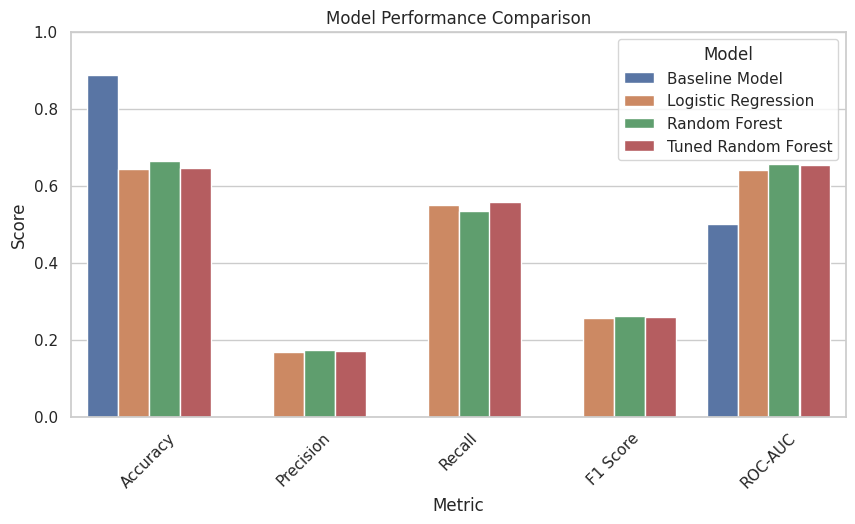

In [ ]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

## 15. Feature Importance for Random Forest

Feature importance helps us understand which variables contribute most to the model.  
Because the preprocessing pipeline uses one-hot encoding, we retrieve transformed feature names from the pipeline.

In [ ]:
# Extract feature names after preprocessing
preprocessor_fitted = rf_model.named_steps["preprocessor"]

numeric_names = numeric_features

categorical_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
categorical_names = categorical_encoder.get_feature_names_out(categorical_features).tolist()

all_feature_names = numeric_names + categorical_names

# Extract feature importances
rf_classifier = rf_model.named_steps["classifier"]
importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
9,number_inpatient,0.128698
11,total_prior_visits,0.124727
1,discharge_disposition_id,0.052143
6,num_medications,0.029177
10,number_diagnoses,0.027791
3,time_in_hospital,0.027790
8,number_emergency,0.026879
4,num_lab_procedures,0.018848
1525,diag_3_250,0.016453
7,number_outpatient,0.015698


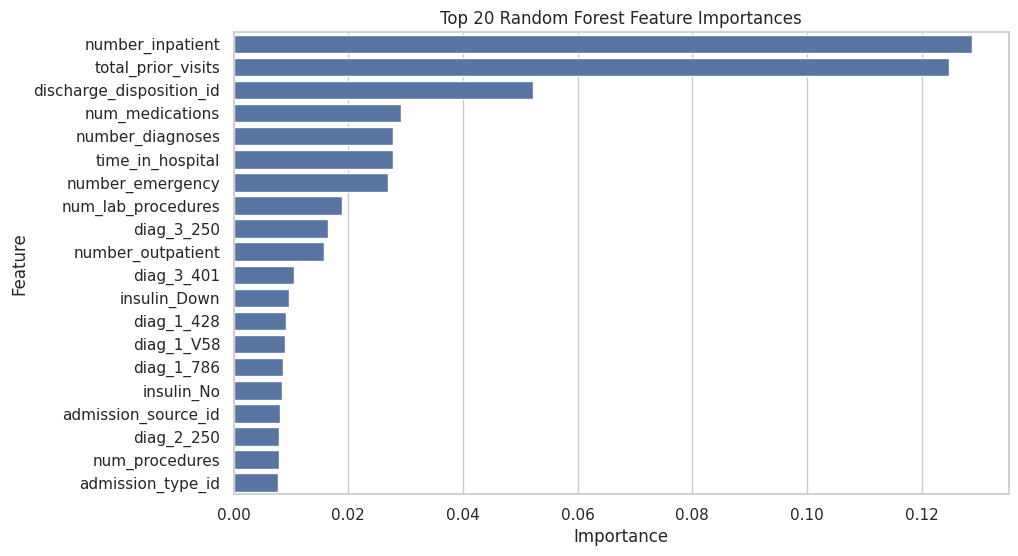

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Patient Risk Group Classification

To make the model more useful for hospital care teams, predicted probabilities were converted into patient risk groups. This allows the model to support discharge planning by identifying patients who may need additional follow-up or care coordination.

In [ ]:
final_model = tuned_rf_model

readmission_probabilities = final_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df["actual_early_readmission"] = y_test.values
risk_df["predicted_probability"] = readmission_probabilities

def assign_risk_group(probability):
    if probability < 0.20:
        return "Low Risk"
    elif probability < 0.50:
        return "Medium Risk"
    else:
        return "High Risk"

risk_df["risk_group"] = risk_df["predicted_probability"].apply(assign_risk_group)

risk_df[["actual_early_readmission", "predicted_probability", "risk_group"]].head(10)

,actual_early_readmission,predicted_probability,risk_group
32065,1,0.490980,Medium Risk
45621,0,0.409828,Medium Risk
64224,0,0.474893,Medium Risk
13039,1,0.503140,High Risk
51982,0,0.470873,Medium Risk
95751,0,0.457559,Medium Risk
2337,0,0.495706,Medium Risk
94717,0,0.506933,High Risk
56432,0,0.486704,Medium Risk
100085,0,0.456872,Medium Risk


In [ ]:
risk_df["risk_group"].value_counts()

,count
risk_group,
Medium Risk,12908
High Risk,7445


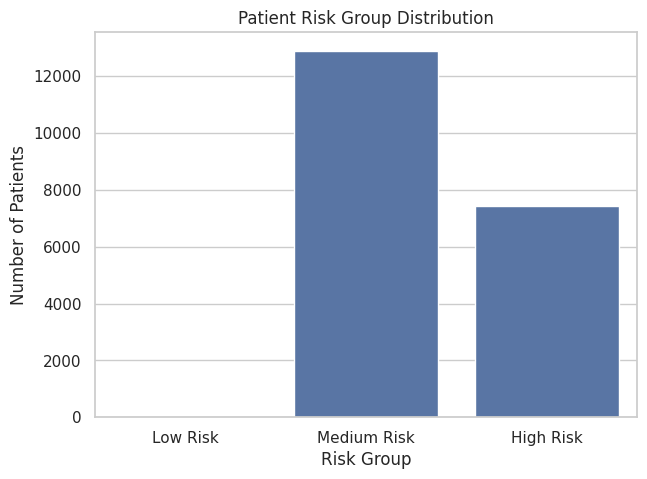

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=risk_df,
    x="risk_group",
    order=["Low Risk", "Medium Risk", "High Risk"]
)
plt.title("Patient Risk Group Distribution")
plt.xlabel("Risk Group")
plt.ylabel("Number of Patients")
plt.show()

## Patient Care Recommendation Framework

The model output was converted into care recommendations so that predictions can support hospital discharge planning.

In [ ]:
care_recommendations = pd.DataFrame({
    "Risk Group": ["Low Risk", "Medium Risk", "High Risk"],
    "Probability Range": ["0% to 20%", "20% to 50%", "50% and above"],
    "Suggested Hospital Action": [
        "Standard discharge instructions",
        "Follow-up appointment and medication review",
        "Care coordination, early follow-up, and closer monitoring"
    ]
})

care_recommendations

,Risk Group,Probability Range,Suggested Hospital Action
0,Low Risk,0% to 20%,Standard discharge instructions
1,Medium Risk,20% to 50%,Follow-up appointment and medication review
2,High Risk,50% and above,"Care coordination, early follow-up, and closer..."


## Fairness Check Across Demographic Groups

Because this dataset includes sensitive demographic features such as age, gender, and race, we checked whether model recall differs across demographic groups. Recall is important because a false negative means the model missed a patient who was actually readmitted within 30 days.

In [ ]:
fairness_df = X_test.copy()
fairness_df["actual"] = y_test.values
fairness_df["predicted"] = final_model.predict(X_test)

def group_metrics(data, group_col):
    rows = []
    for group in data[group_col].dropna().unique():
        subset = data[data[group_col] == group]
        rows.append({
            "Group": group,
            "Count": len(subset),
            "Precision": precision_score(subset["actual"], subset["predicted"], zero_division=0),
            "Recall": recall_score(subset["actual"], subset["predicted"], zero_division=0),
            "F1 Score": f1_score(subset["actual"], subset["predicted"], zero_division=0)
        })
    return pd.DataFrame(rows)

age_fairness = group_metrics(fairness_df, "age")
gender_fairness = group_metrics(fairness_df, "gender")
race_fairness = group_metrics(fairness_df, "race")

In [ ]:
age_fairness

,Group,Count,Precision,Recall,F1 Score
0,[60-70),4485,0.171895,0.517958,0.258125
1,[70-80),5300,0.163645,0.546178,0.251836
2,[50-60),3489,0.162791,0.558140,0.252063
3,[40-50),1902,0.202303,0.654255,0.309045
4,[80-90),3430,0.153453,0.566038,0.241449
5,[90-100),567,0.171548,0.554054,0.261981
6,[30-40),692,0.206186,0.512821,0.294118
7,[20-30),324,0.300971,0.720930,0.424658
8,[0-10),38,0.000000,0.000000,0.000000
9,[10-20),126,0.285714,0.666667,0.400000


In [ ]:
gender_fairness

,Group,Count,Precision,Recall,F1 Score
0,Male,9298,0.16866,0.541339,0.257190
1,Female,11055,0.17065,0.568924,0.262548


In [ ]:
race_fairness

,Group,Count,Precision,Recall,F1 Score
0,Caucasian,15203,0.169861,0.562609,0.260940
1,AfricanAmerican,3882,0.169731,0.555556,0.260022
2,Hispanic,403,0.266667,0.560000,0.361290
3,Other,283,0.103448,0.450000,0.168224
4,Asian,113,0.100000,0.300000,0.150000


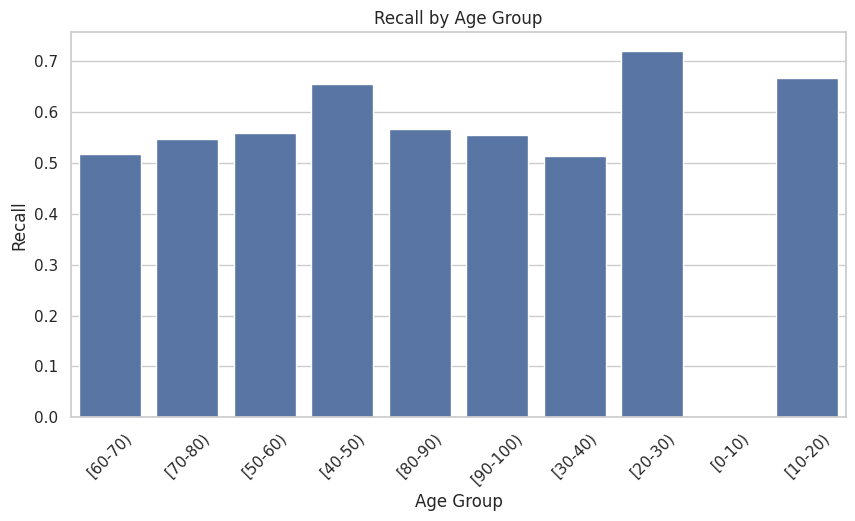

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=age_fairness, x="Group", y="Recall")
plt.title("Recall by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.show()